# Forecast Using the T0 Family


TimeCopilot ships a single `T0` class for The Forecasting Company open-weights checkpoints. Pass the Hugging Face `repo_id` to select the model:

| Release | `repo_id` | Size |
|---------|-----------|------|
| **T0 alpha** (default) | `theforecastingcompany/t0-alpha` | ~102M |
| **T0 beta** | `theforecastingcompany/t0-beta` | ~256M |

*Requirements*:

    - Python 3.11 – 3.13
    - `foundationforecast>=0.1.8` (pulls `tfc-t0>=0.5.0` for beta)
    - CUDA recommended (CPU works but is slower)

**Quantiles:** `t0-alpha` uses 5 native quantile knots; `t0-beta` uses 21 levels (0.01–0.99). Pass `level` or `quantiles`; requested levels are interpolated from native knots.



## Import libraries


In [1]:
import sys

import pandas as pd

from timecopilot import TimeCopilotForecaster

if sys.version_info < (3, 11) or sys.version_info >= (3, 14):
    raise RuntimeError("T0 requires Python >= 3.11 and < 3.14")


INFO:datasets:JAX version 0.7.1 available.
2026-09-29 13:59:22,270	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-09-29 13:59:22,616	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Load the dataset

The DataFrame must include at least the following columns:
- unique_id: Unique identifier for each time series (string)
- ds: Date column (datetime format)
- y: Target variable for forecasting (float format)


In [2]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()


,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Plot the data


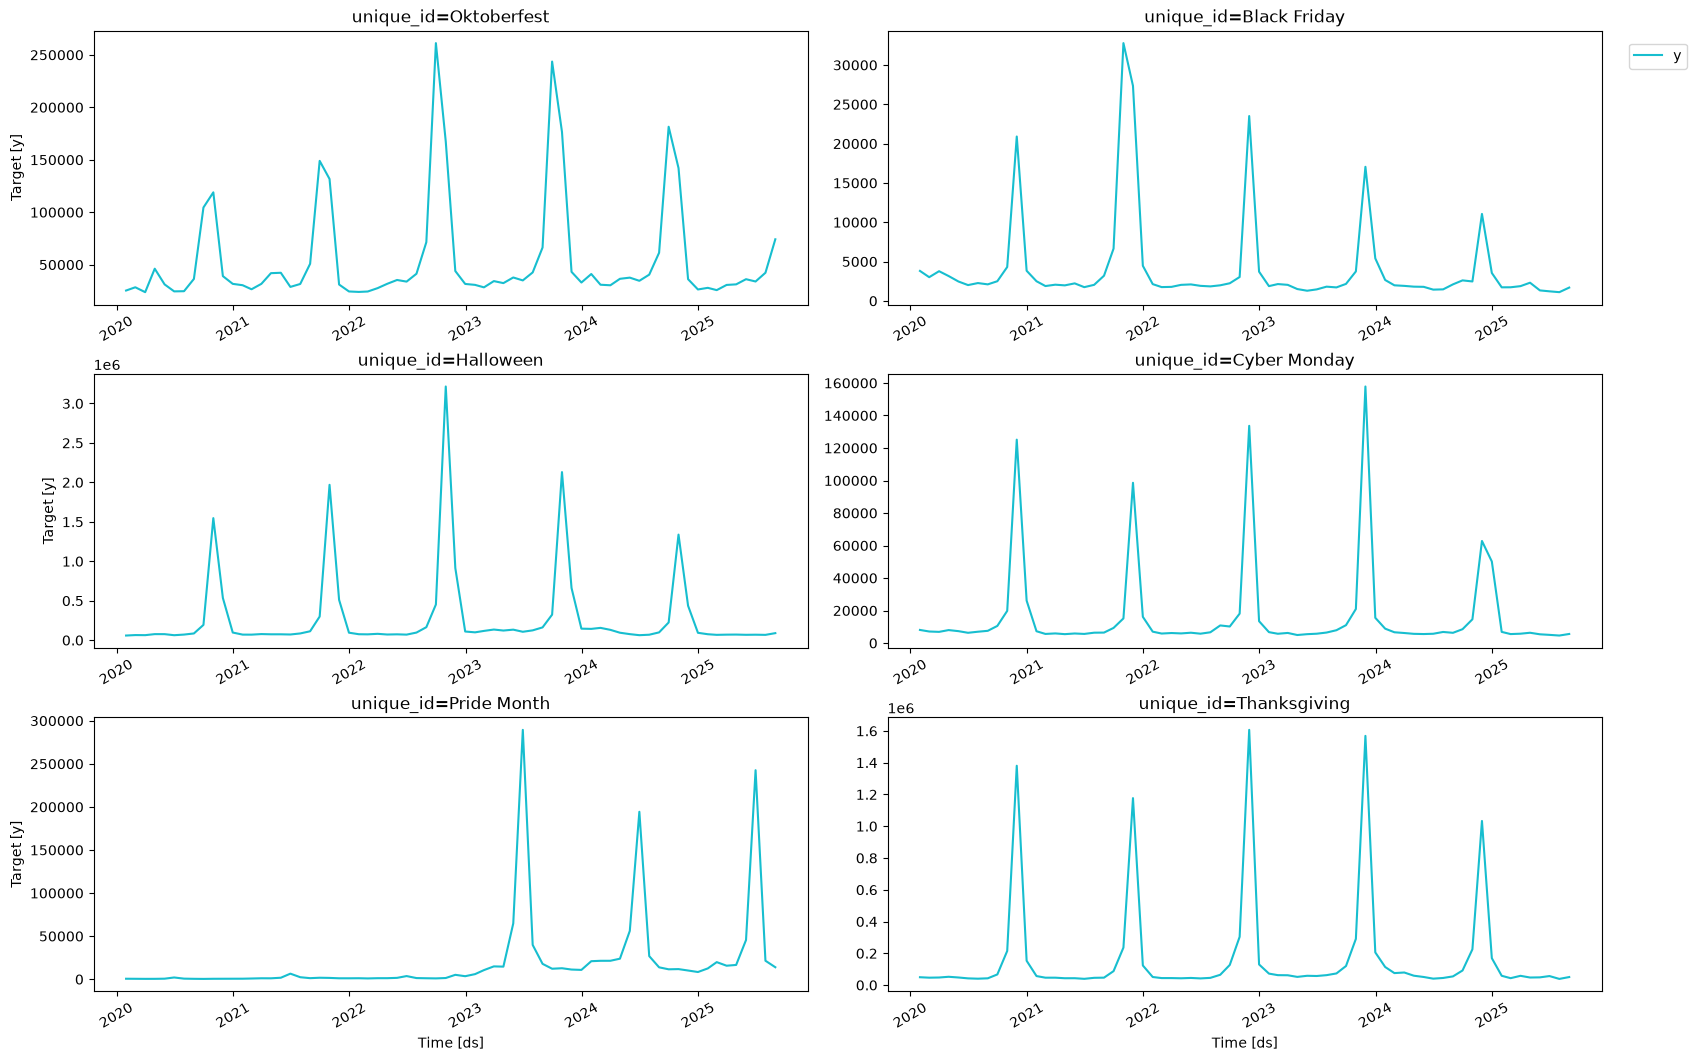

In [3]:
TimeCopilotForecaster.plot(df)


## Create a TimeCopilotForecaster

We compare T0 alpha and beta. Each model gets a distinct `alias` so forecasts are easy to identify.


In [4]:
from timecopilot.models.foundation.t0 import T0

context_length = 512
batch_size = 8

models = [
    T0(
        repo_id="theforecastingcompany/t0-alpha",
        alias="t0-alpha",
        context_length=context_length,
        batch_size=batch_size,
    ),
    T0(
        repo_id="theforecastingcompany/t0-beta",
        alias="t0-beta",
        context_length=context_length,
        batch_size=batch_size,
    ),
]

tcf = TimeCopilotForecaster(models=models)


## Cross-validate with prediction intervals

Beta supports fine-grained quantiles; alpha interpolates from its 5 native knots.


In [5]:
level = [80, 90]
h = 12
cv_df = tcf.cross_validation(df=df, h=h, level=level)
cv_df.head()


0it [00:00, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
100%|██████████| 1/1 [00:00<00:00, 33.07it/s]
1it [00:01,  1.36s/it]
100%|██████████| 1/1 [00:00<00:00, 12.14it/s]
1it [00:04,  4.24s/it]


,unique_id,ds,cutoff,y,t0-alpha,t0-alpha-lo-80,t0-alpha-hi-80,t0-alpha-lo-90,t0-alpha-hi-90,t0-beta,t0-beta-lo-80,t0-beta-hi-80,t0-beta-lo-90,t0-beta-hi-90
0,Black Friday,2024-09-30,2024-08-31,2607,2116.718506,1641.902588,3565.373779,1641.902588,3565.373779,2067.666260,1619.116943,2988.298828,1468.435547,4289.673828
1,Black Friday,2024-10-31,2024-08-31,2470,2536.804688,1639.148682,7205.684570,1639.148682,7205.684570,2855.733154,1799.611572,7728.554199,1571.173096,12572.298828
2,Black Friday,2024-11-30,2024-08-31,11058,10990.619141,2503.651855,23642.492188,2503.651855,23642.492188,10715.068359,1846.131592,27632.449219,1418.302246,32104.906250
3,Black Friday,2024-12-31,2024-08-31,3548,4139.507812,1690.802002,22400.281250,1690.802002,22400.281250,6946.167969,1764.462891,22927.335938,1441.465332,28249.667969
4,Black Friday,2025-01-31,2024-08-31,1724,2066.241943,1512.723145,3874.775635,1512.723145,3874.775635,2339.218750,1589.121826,5747.300781,1378.156006,9279.615234


## Plot forecast comparison

One panel per event series. Each panel overlays T0 alpha and beta; **t0-beta** is highlighted with its 80% prediction interval. Saved to `t0-family-forecast.png`.


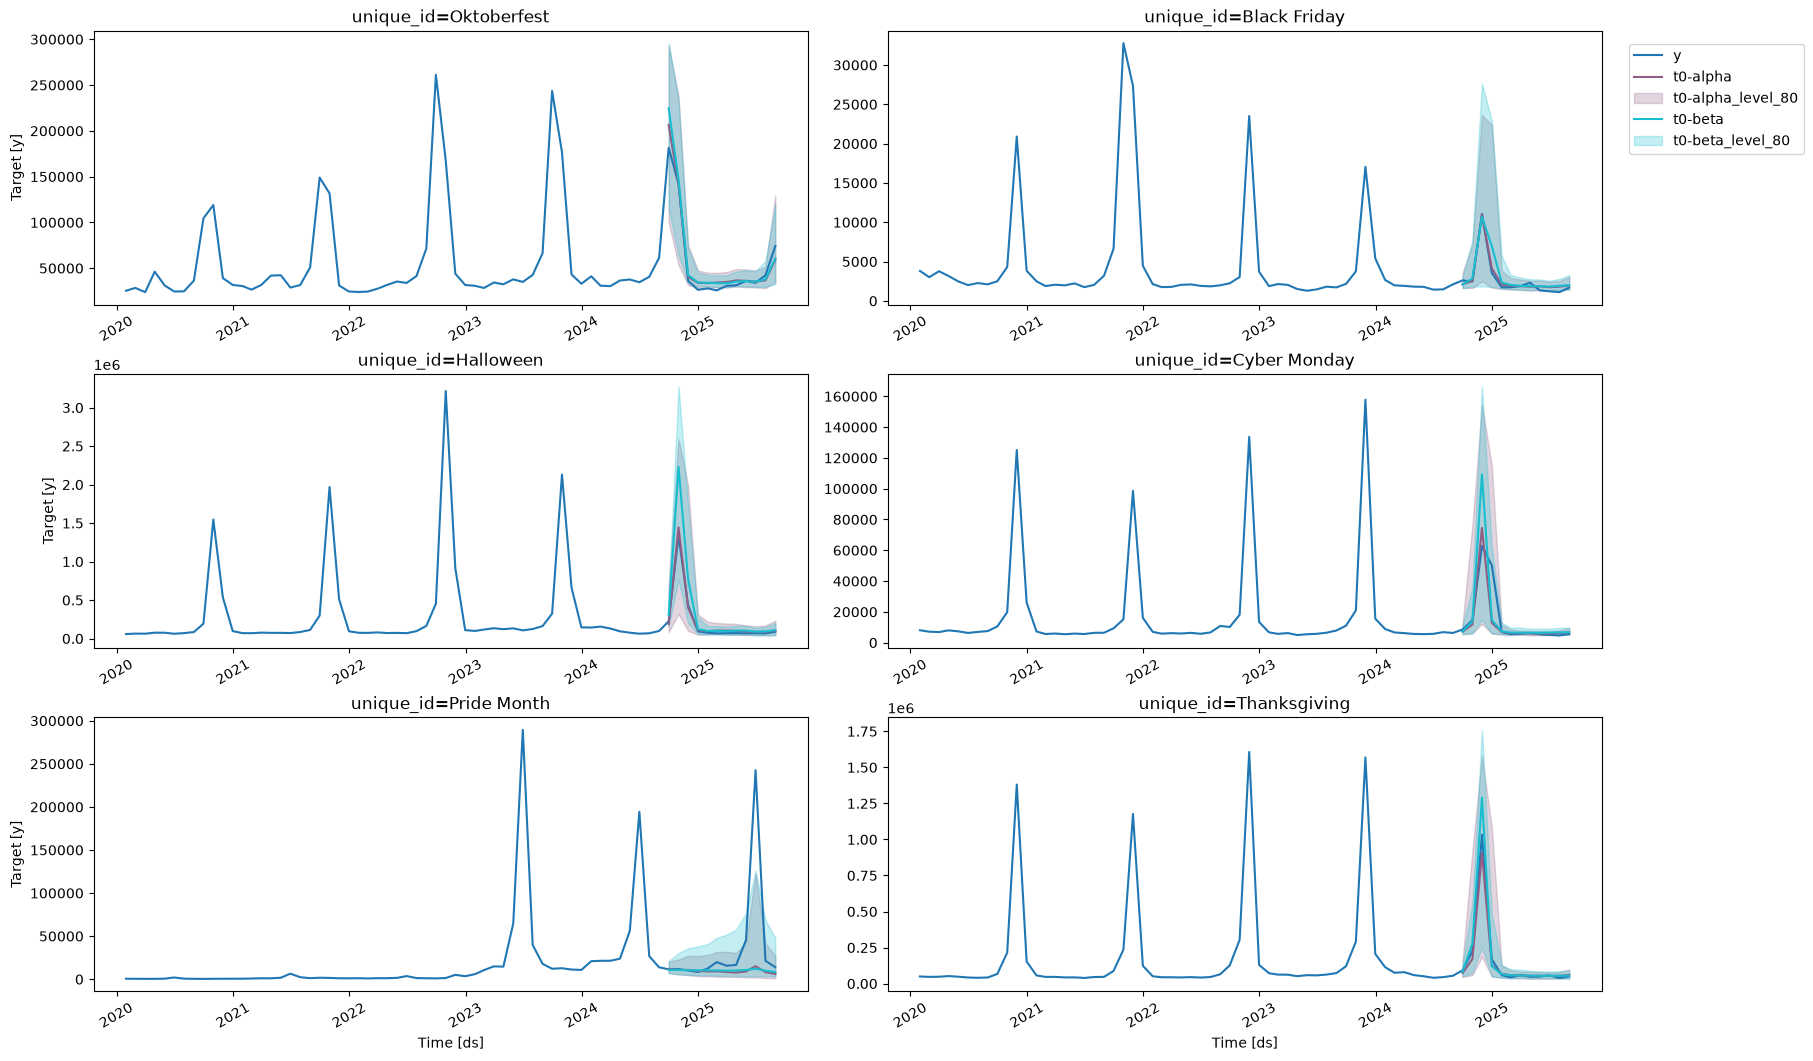

In [6]:
tcf.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])

## Evaluate


In [8]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

metrics_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
metrics_df.groupby("metric").mean(numeric_only=True).T.sort_values(
    by="scaled_crps"
).round(3)


metric,mase,scaled_crps
t0-beta,1.279,0.166
t0-alpha,0.883,0.177
